# Notebook 06: Clinical Demo

Single-record inference on the held-out test set (`strat_fold == 10`).
Loads the best-performing transformer, runs a prediction, and presents
results in a clinician-facing format with full 12-lead ECG plot and
a focused-leads view for any HIGH-risk diagnoses.

Change `RECORD_ID` in the second cell to test different records.

In [1]:
import sys, os, json, warnings
sys.path.append('../')
os.environ['TRANSFORMERS_OFFLINE'] = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import torch
import matplotlib.pyplot as plt
import wfdb

from src.utils.config               import CFG
from src.preprocessing.label_utils  import load_all_labels
from src.inference.loaders          import load_hubert_blocks, load_hubert_peft, load_leadwise
from src.inference.predict          import predict_proba

DATA_PATH    = CFG['data']['path']
RESULTS      = CFG['paths']['results']
SUPERCLASSES = CFG['data']['superclasses']
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
LEAD_IDX   = {name: i for i, name in enumerate(LEAD_NAMES)}

DIAGNOSIS_LEADS = {
    'MI':   ['II', 'III', 'aVF', 'V1', 'V2', 'V3', 'V4'],
    'STTC': ['I', 'aVL', 'V4', 'V5', 'V6'],
    'CD':   ['V1', 'V2', 'aVL'],
    'HYP':  ['I', 'aVL', 'V5', 'V6'],
    'NORM': [],
}

# Identify best transformer from saved history.json files
HIST_NAMES = {
    'HuBERT selective 8b': 'hubert_ecg_blocks8',
    'HuBERT LoRA r=8':     'hubert_ecg_lora_r8',
    'HuBERT DoRA r=8':     'hubert_ecg_dora_r8',
    'Leadwise (full)':     'leadwise_transformer',
}

def _best_auc(exp_name):
    p = os.path.join(RESULTS, exp_name, 'history.json')
    return json.load(open(p))['best_auc'] if os.path.exists(p) else 0.0

BEST_NAME = max(HIST_NAMES, key=lambda k: _best_auc(HIST_NAMES[k]))
BEST_AUC  = _best_auc(HIST_NAMES[BEST_NAME])
print(f'Best transformer : {BEST_NAME}  |  AUC {BEST_AUC:.4f}')

Best transformer : HuBERT selective 8b  |  AUC 0.8826


In [2]:
# -- Change RECORD_ID to test a different record ------------------------------
RECORD_ID      = None   # None = use first record in test set
PRED_THRESHOLD = 0.50   # sigmoid prob >= this -> POSITIVE
RISK_THRESHOLD = 0.70   # positive AND prob >= this -> HIGH risk
# -----------------------------------------------------------------------------

Y       = load_all_labels(DATA_PATH + 'ptbxl_database.csv', DATA_PATH + 'scp_statements.csv')
test_df = Y[Y.strat_fold == 10]

if RECORD_ID is None:
    RECORD_ID = int(test_df.index[0])
    print(f'Using default RECORD_ID = {RECORD_ID}')

assert RECORD_ID in test_df.index, (
    f'Record {RECORD_ID} is not in the held-out test set (strat_fold==10). '
    f'Choose an ID from test_df.index.'
)

row         = test_df.loc[RECORD_ID]
true_labels = list(row['label_vec'])
true_names  = [SUPERCLASSES[i] for i, v in enumerate(true_labels) if v == 1]

signal, fields = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
t = np.linspace(0, 10, signal.shape[0])

print(f'Record {RECORD_ID} loaded: shape {signal.shape}')
print(f'True labels : {dict(zip(SUPERCLASSES, [int(v) for v in true_labels]))}')
print(f'True classes: {true_names}')

Records with valid labels: 21388
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5235 (24.5%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)
Using default RECORD_ID = 9
Record 9 loaded: shape (1000, 12)
True labels : {'NORM': 1, 'MI': 0, 'STTC': 0, 'CD': 0, 'HYP': 0}
True classes: ['NORM']


In [3]:
# Load best transformer and run inference on this single record
LOADER_MAP = {
    'HuBERT selective 8b': lambda: load_hubert_blocks(n=8),
    'HuBERT LoRA r=8':     lambda: load_hubert_peft(rank=8, use_dora=False),
    'HuBERT DoRA r=8':     lambda: load_hubert_peft(rank=8, use_dora=True),
    'Leadwise (full)':     lambda: load_leadwise(),
}

model, ds_cls = LOADER_MAP[BEST_NAME]()
single_ds     = ds_cls(test_df.loc[[RECORD_ID]], DATA_PATH)
probs, _      = predict_proba(model.to(device), single_ds, device)
probs         = probs[0].numpy()   # (5,)

del model; torch.cuda.empty_cache()
print(f'Probabilities: {dict(zip(SUPERCLASSES, [round(float(p), 4) for p in probs]))}')

Loading HuBERT-ECG-base...
Loaded.
Unfrozen 128 tensors from last 8 blocks (layers 4–11)
Trainable: 56,902,661 / 93,323,397 (61.0%)
Probabilities: {'NORM': 0.9057, 'MI': 0.0303, 'STTC': 0.0052, 'CD': 0.2285, 'HYP': 0.0319}


In [4]:
preds    = (probs >= PRED_THRESHOLD).astype(int)
risk     = [
    'HIGH' if (preds[i] == 1 and probs[i] >= RISK_THRESHOLD) else 'LOW'
    for i in range(len(SUPERCLASSES))
]
flagged  = [SUPERCLASSES[i] for i in range(len(SUPERCLASSES)) if preds[i] == 1]
high_cls = [SUPERCLASSES[i] for i in range(len(SUPERCLASSES)) if risk[i] == 'HIGH']

print('=================================================')
print('CLINICAL DECISION SUPPORT REPORT')
print(f'Record ID : {RECORD_ID}    |  Test set: confirmed')
print(f'Model     : {BEST_NAME}  |  AUC {BEST_AUC:.4f}')
print('=================================================')
print(f'Thresholds: prediction >= {PRED_THRESHOLD}  |  HIGH risk >= {RISK_THRESHOLD}')
print('-------------------------------------------------')
print(f'{"Class":<8} {"Prob":>6}  {"Prediction":<12} Risk')
print('-' * 42)
for i, cls in enumerate(SUPERCLASSES):
    pred_str = 'POSITIVE' if preds[i] == 1 else 'NEGATIVE'
    print(f'{cls:<8} {probs[i]:>6.3f}  {pred_str:<12} {risk[i]}')
print('-' * 42)
print(f'True labels : {", ".join(true_names) if true_names else "None"}')
print(f'Flagged     : {", ".join(flagged) if flagged else "None"}')
if high_cls:
    print(f'Risk HIGH   : {", ".join(high_cls)}')
else:
    print('Risk HIGH   : None')
print('DISCLAIMER: Research use only.')
print('=================================================')

CLINICAL DECISION SUPPORT REPORT
Record ID : 9    |  Test set: confirmed
Model     : HuBERT selective 8b  |  AUC 0.8826
Thresholds: prediction >= 0.5  |  HIGH risk >= 0.7
-------------------------------------------------
Class      Prob  Prediction   Risk
------------------------------------------
NORM      0.906  POSITIVE     HIGH
MI        0.030  NEGATIVE     LOW
STTC      0.005  NEGATIVE     LOW
CD        0.228  NEGATIVE     LOW
HYP       0.032  NEGATIVE     LOW
------------------------------------------
True labels : NORM
Flagged     : NORM
Risk HIGH   : NORM
DISCLAIMER: Research use only.


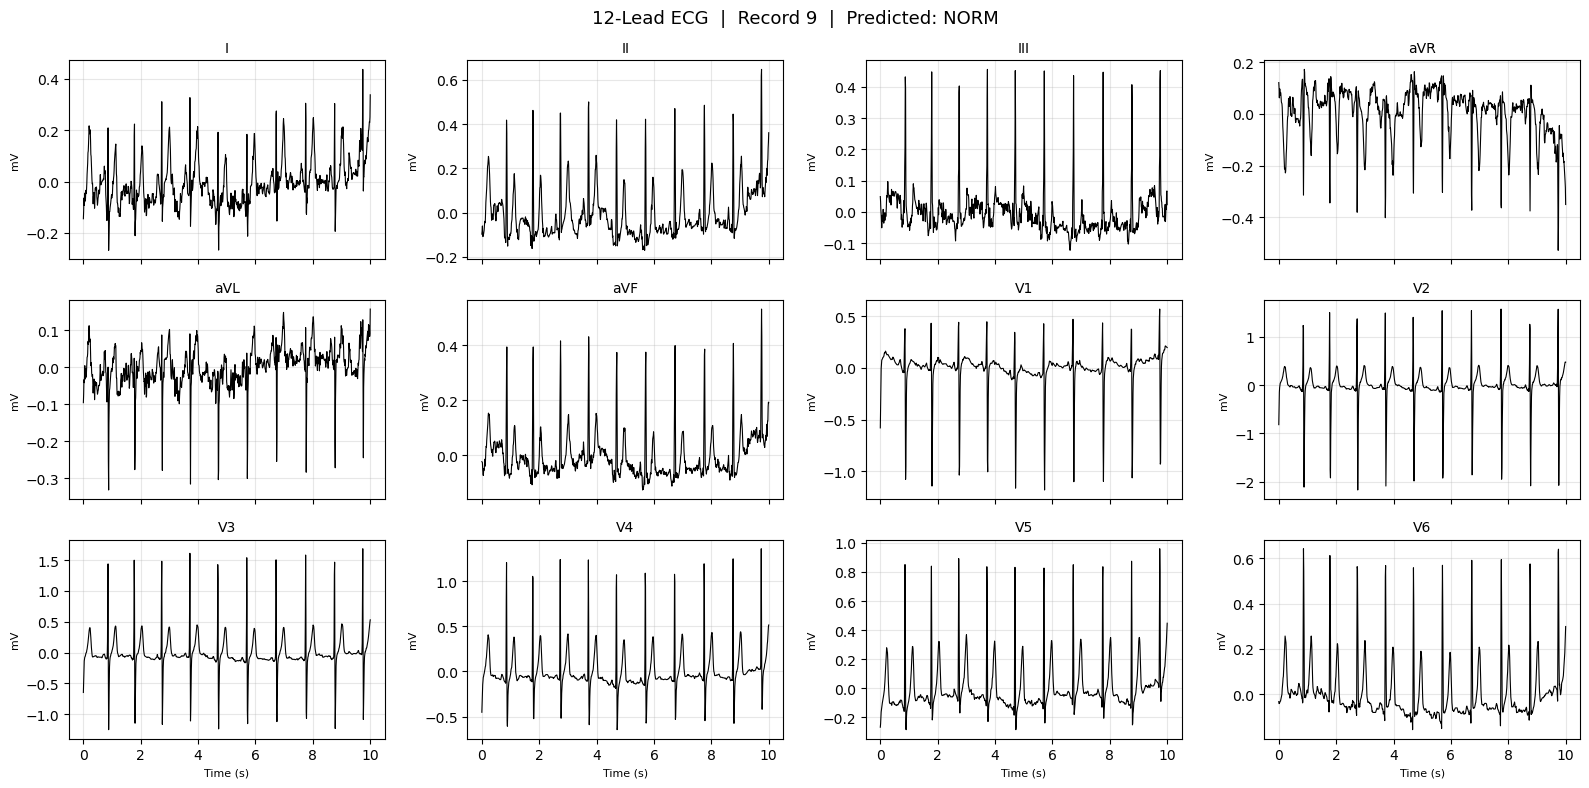

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for i, lead_name in enumerate(LEAD_NAMES):
    axes[i].plot(t, signal[:, LEAD_IDX[lead_name]], linewidth=0.8, color='black')
    axes[i].set_title(lead_name, fontsize=10)
    axes[i].set_ylabel('mV', fontsize=8)
    axes[i].grid(True, alpha=0.3)

for ax in axes[8:]:
    ax.set_xlabel('Time (s)', fontsize=8)

flagged_str = ', '.join(flagged) if flagged else 'None'
fig.suptitle(
    f'12-Lead ECG  |  Record {RECORD_ID}  |  Predicted: {flagged_str}',
    fontsize=13
)
plt.tight_layout()
plt.show()

In [6]:
if not high_cls:
    print('No HIGH-risk flags -- full 12-lead plot above is sufficient.')
else:
    relevant = []
    for cls in high_cls:
        for lead in DIAGNOSIS_LEADS.get(cls, []):
            if lead not in relevant:
                relevant.append(lead)

    if not relevant:
        print('No HIGH-risk flags -- full 12-lead plot above is sufficient.')
    else:
        n = len(relevant)
        fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n), sharex=True)
        if n == 1:
            axes = [axes]

        for i, lead_name in enumerate(relevant):
            axes[i].plot(t, signal[:, LEAD_IDX[lead_name]],
                         linewidth=0.9, color='darkred')
            axes[i].set_title(f'Lead {lead_name}', fontsize=10)
            axes[i].set_ylabel('mV', fontsize=8)
            axes[i].grid(True, alpha=0.3)

        axes[-1].set_xlabel('Time (s)', fontsize=9)
        fig.suptitle(
            f'Focused Leads for HIGH-Risk: {", ".join(high_cls)}  |  Record {RECORD_ID}',
            fontsize=12
        )
        plt.tight_layout()
        plt.show()

No HIGH-risk flags -- full 12-lead plot above is sufficient.
